<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week3_Day2_Exercises_XP_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXERCICE  1

In [1]:
import pandas as pd
import zipfile
import requests
import io
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

url_titanic = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20&%20T/titanic%20dataset.zip"

response = requests.get(url_titanic)
z = zipfile.ZipFile(io.BytesIO(response.content))
titanic_df = pd.read_csv(z.open("titanic dataset/train.csv"))
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
rows_before = len(titanic_df)
print(f"Rows before       : {rows_before}")
print(f"Duplicates found  : {titanic_df.duplicated().sum()}")

titanic_df = titanic_df.drop_duplicates()

rows_after = len(titanic_df)
print(f"Rows after        : {rows_after}")
print(f"Rows removed      : {rows_before - rows_after}")

Rows before       : 891
Duplicates found  : 0
Rows after        : 891
Rows removed      : 0


EXERCICE  2

In [3]:
# Step 1 : Identify
print(titanic_df.isnull().sum())
print((titanic_df.isnull().sum() / len(titanic_df) * 100).round(2))

# Step 2 : Drop Cabin (77% missing)
titanic_df = titanic_df.drop(columns=["Cabin"])

# Step 3 : Impute Age with mean
imputer = SimpleImputer(strategy="mean")
titanic_df["Age"] = imputer.fit_transform(titanic_df[["Age"]])

# Step 4 : Fill Embarked with mode
titanic_df["Embarked"] = titanic_df["Embarked"].fillna(
    titanic_df["Embarked"].mode()[0]
)

print("\nMissing values after treatment :")
print(titanic_df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

Missing values after treatment :
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


EXERCICE  3

In [4]:
# Feature 1 : FamilySize
titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1

# Feature 2 : Title
titanic_df["Title"] = titanic_df["Name"].str.extract(r',\s*([^\.]+)\.')
titanic_df["Title"] = titanic_df["Title"].replace(
    ["Dr", "Rev", "Col", "Mlle", "Major", "Ms",
     "Mme", "Don", "Lady", "Sir", "Capt",
     "the Countess", "Jonkheer"], "Rare"
)

# Encoding : Label Encoding on Title
le = LabelEncoder()
titanic_df["Title_Encoded"] = le.fit_transform(titanic_df["Title"])

# Encoding : One-hot on Sex and Embarked
titanic_df = pd.get_dummies(titanic_df, columns=["Sex", "Embarked"])

print(titanic_df.columns.tolist())
titanic_df.head()

['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'FamilySize', 'Title', 'Title_Encoded', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,FamilySize,Title,Title_Encoded,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,2,Mr,2,False,True,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,2,Mrs,3,True,False,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1,Miss,1,True,False,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,2,Mrs,3,True,False,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,Mr,2,False,True,False,False,True


EXERCICE 4

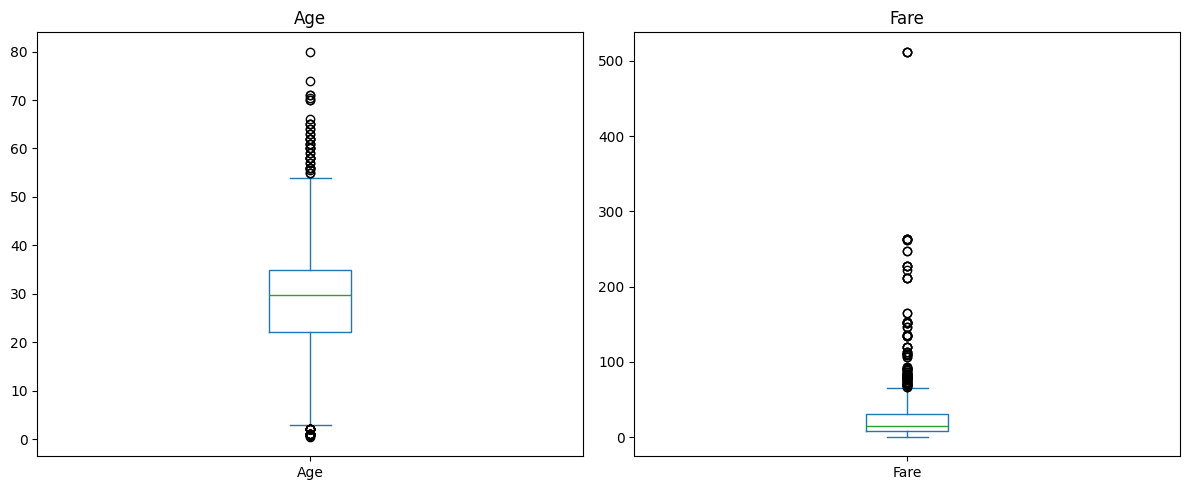

Age outliers : 66
Fare outliers : 116

Rows after outlier removal : 884
Fare max before capping : 512.33
Fare max after capping  : 211.34


In [5]:
# Step 1 : Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
titanic_df["Age"].plot(kind="box", ax=axes[0], title="Age")
titanic_df["Fare"].plot(kind="box", ax=axes[1], title="Fare")
plt.tight_layout()
plt.show()

# Step 2 : IQR method
for col in ["Age", "Fare"]:
    Q1 = titanic_df[col].quantile(0.25)
    Q3 = titanic_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((titanic_df[col] < Q1 - 1.5 * IQR) |
                (titanic_df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"{col} outliers : {outliers}")

# Step 3a : Quantile capping on Fare
cap = titanic_df["Fare"].quantile(0.98)
titanic_df["Fare_Capped"] = titanic_df["Fare"].clip(upper=cap)

# Step 3b : Log transformation on Fare
titanic_df["Fare_Log"] = np.log1p(titanic_df["Fare"])

# Step 3c : Row removal on Age (Z-score > 3)
from scipy import stats
titanic_df = titanic_df[np.abs(stats.zscore(titanic_df["Age"])) < 3]

# Step 4 : Compare
print(f"\nRows after outlier removal : {len(titanic_df)}")
print(f"Fare max before capping : {titanic_df['Fare'].max():.2f}")
print(f"Fare max after capping  : {titanic_df['Fare_Capped'].max():.2f}")

EXERCICE  5

In [6]:
# StandardScaler on Age (normally distributed)
scaler_std = StandardScaler()
titanic_df["Age_Scaled"] = scaler_std.fit_transform(titanic_df[["Age"]])

# MinMaxScaler on Fare_Log (skewed)
scaler_mm = MinMaxScaler()
titanic_df["Fare_Normalized"] = scaler_mm.fit_transform(titanic_df[["Fare_Log"]])

print(titanic_df[["Age", "Age_Scaled", "Fare_Log", "Fare_Normalized"]].head())

    Age  Age_Scaled  Fare_Log  Fare_Normalized
0  22.0   -0.590161  2.110213         0.338125
1  38.0    0.692566  4.280593         0.685892
2  26.0   -0.269479  2.188856         0.350727
3  35.0    0.452055  3.990834         0.639463
4  35.0    0.452055  2.202765         0.352955


EXERCICE 6

In [7]:
# Check remaining categorical columns
remaining_cat = titanic_df.select_dtypes(include="object").columns.tolist()
print("Remaining categorical columns :", remaining_cat)

# Drop columns not needed for modeling
titanic_df = titanic_df.drop(columns=["Name", "Ticket", "Title"])

print("Final columns :", titanic_df.columns.tolist())

Remaining categorical columns : ['Name', 'Ticket', 'Title']
Final columns : ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Title_Encoded', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Fare_Capped', 'Fare_Log', 'Age_Scaled', 'Fare_Normalized']


EXERCICE 7

In [8]:
# Create age bins
titanic_df["AgeGroup"] = pd.cut(
    titanic_df["Age"],
    bins=[0, 12, 18, 60, 100],
    labels=["Child", "Teen", "Adult", "Senior"]
)

print(titanic_df["AgeGroup"].value_counts())

# One-hot encoding
titanic_df = pd.get_dummies(titanic_df, columns=["AgeGroup"])

print(titanic_df.columns.tolist())
titanic_df.head()

AgeGroup
Adult     730
Teen       70
Child      69
Senior     15
Name: count, dtype: int64
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Title_Encoded', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Fare_Capped', 'Fare_Log', 'Age_Scaled', 'Fare_Normalized', 'AgeGroup_Child', 'AgeGroup_Teen', 'AgeGroup_Adult', 'AgeGroup_Senior']


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Title_Encoded,Sex_female,...,Embarked_Q,Embarked_S,Fare_Capped,Fare_Log,Age_Scaled,Fare_Normalized,AgeGroup_Child,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_Senior
0,1,0,3,22.0,1,0,7.2500,2,2,False,...,False,True,7.2500,2.110213,-0.590161,0.338125,False,False,True,False
1,2,1,1,38.0,1,0,71.2833,2,3,True,...,False,False,71.2833,4.280593,0.692566,0.685892,False,False,True,False
2,3,1,3,26.0,0,0,7.9250,1,1,True,...,False,True,7.9250,2.188856,-0.269479,0.350727,False,False,True,False
3,4,1,1,35.0,1,0,53.1000,2,3,True,...,False,True,53.1000,3.990834,0.452055,0.639463,False,False,True,False
4,5,0,3,35.0,0,0,8.0500,1,2,False,...,False,True,8.0500,2.202765,0.452055,0.352955,False,False,True,False
